In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('base_data_v3_soil_corrected.csv')
sns.set_style("whitegrid")

--- Analyzing Transformed Target Variable: 'yield_log1p' ---
count    16153.000000
mean         0.817421
std          0.878684
min          0.000000
25%          0.273848
50%          0.510826
75%          0.963893
max          4.843841
Name: yield_log1p, dtype: float64


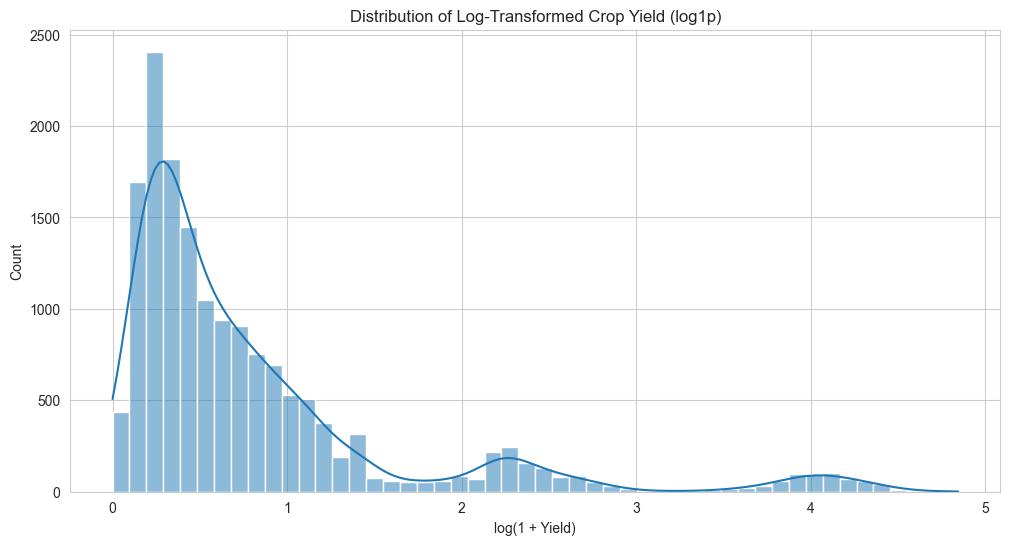

In [2]:
# Create a new column for the transformed yield
df['yield_log1p'] = np.log1p(df['yield'])

# Verify the transformation
print("--- Analyzing Transformed Target Variable: 'yield_log1p' ---")
print(df['yield_log1p'].describe())

plt.figure(figsize=(12, 6))
sns.histplot(df['yield_log1p'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Crop Yield (log1p)')
plt.xlabel('log(1 + Yield)')
plt.show() 

# We will now use 'yield_log1p' as our target for modeling.
# Drop the original 'yield' column to avoid confusion.
df = df.drop(columns=['yield'])

In [3]:
from sklearn.preprocessing import MultiLabelBinarizer

# Fill the NaN for Jharsuguda with a placeholder (e.g., 'Unknown') 
# Or, based on research, impute a likely soil type if known. Let's use 'Unknown'.
df['primary_soil_type'] = df['primary_soil_type'].fillna('Unknown')

# Split the strings into lists of soil types
soil_lists = df['primary_soil_type'].apply(lambda x: [s.strip() for s in x.split(',')])

# Use MultiLabelBinarizer to create binary columns
mlb = MultiLabelBinarizer()
soil_encoded = mlb.fit_transform(soil_lists)

# Create a new DataFrame with these columns, prefixing names with 'soil_'
soil_df = pd.DataFrame(soil_encoded, columns=['soil_' + cls.lower().replace(' ', '_').replace('&', 'and') for cls in mlb.classes_])

# Concatenate this back to the original DataFrame
df = pd.concat([df.reset_index(drop=True), soil_df.reset_index(drop=True)], axis=1)

# Drop the original 'primary_soil_type' column
df = df.drop(columns=['primary_soil_type'])

print("\n--- Soil Type Columns Created ---")
print(df.filter(like='soil_').head())


--- Soil Type Columns Created ---
   soil_black  soil_black_soil  soil_brown_forest  \
0           0                1                  0   
1           0                1                  0   
2           1                0                  0   
3           1                0                  0   
4           1                0                  0   

   soil_coastal_salt_affected_alluvial  soil_deltaic_alluvial  soil_laterite  \
0                                    0                      0              0   
1                                    0                      0              0   
2                                    0                      0              0   
3                                    0                      0              0   
4                                    0                      0              0   

   soil_mixed_red_and_black  soil_mixed_red_and_yellow  soil_red  \
0                         0                          0         0   
1                         0  

In [4]:
# One-hot encode 'district' and 'season'
df = pd.get_dummies(df, columns=['district', 'season'], drop_first=False) # Keep all districts/seasons for now

print("\n--- DataFrame Info After Initial Encoding ---")
df.info()


--- DataFrame Info After Initial Encoding ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16153 entries, 0 to 16152
Data columns (total 57 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   crop                                 16153 non-null  object 
 1   year                                 16153 non-null  int64  
 2   area                                 16153 non-null  float64
 3   avg_temp_c                           16153 non-null  float64
 4   total_precip_mm                      16153 non-null  float64
 5   mean_ph                              2525 non-null   float64
 6   mean_n                               2022 non-null   float64
 7   mean_p                               2525 non-null   float64
 8   mean_k                               2022 non-null   float64
 9   yield_log1p                          16153 non-null  float64
 10  soil_black                           16153 non-

In [5]:
df.to_csv('features_v1_partial.csv', index=False)

In [1]:
import pandas as pd
import numpy as np

# Load the data BEFORE crop frequency encoding was applied
df = pd.read_csv('base_data_v3_soil_corrected.csv') 

# Apply initial transformations again (log yield, drop original yield, soil binarization, district/season OHE)
# --- Re-run the relevant cells from Task 4 ---
# Log transform yield
df['yield_log1p'] = np.log1p(df['yield'])
df = df.drop(columns=['yield'])

# Soil Type Binarization (copy from Task 4)
from sklearn.preprocessing import MultiLabelBinarizer
df['primary_soil_type'] = df['primary_soil_type'].fillna('Unknown')
soil_lists = df['primary_soil_type'].apply(lambda x: [s.strip() for s in x.split(',')])
mlb = MultiLabelBinarizer()
soil_encoded = mlb.fit_transform(soil_lists)
soil_df = pd.DataFrame(soil_encoded, columns=['soil_' + cls.lower().replace(' ', '_').replace('&', 'and') for cls in mlb.classes_])
df = pd.concat([df.reset_index(drop=True), soil_df.reset_index(drop=True)], axis=1)
df = df.drop(columns=['primary_soil_type'])

# District/Season OHE (copy from Task 4)
df = pd.get_dummies(df, columns=['district', 'season'], drop_first=False)

# Impute Soil Nutrients (copy from Task 5 - relies on soil binary cols being present)
# [Include the full imputation code from Task 5 here]
# ... (Make sure nutrient_cols are filled, df has no nulls in them) ...
# Ensure all nutrient columns are now filled. Check df[nutrient_cols].isnull().sum() again.
# --- End of re-running previous steps ---

In [3]:
# --- Start: Impute Missing Soil Nutrients ---
print("\n--- Part C: Imputing Missing Soil Nutrients ---")
 
 # Reload the original soil nutrient and type dataframes (corrected) for mapping
 # (Copy this corrected data structure from the Task 2.1 script)
soil_type_data = {
     'district': [
         'anugul', 'baleshwar', 'bargarh', 'bhadrak', 'balangir', 'boudh', 
         'cuttack', 'deogarh', 'dhenkanal', 'gajapati', 'ganjam', 
         'jagatsinghapur', 'jajapur', 'jharsuguda', 'kalahandi', 'kandhamal', 
         'kendrapara', 'kendujhar', 'khordha', 'koraput', 'malkangiri', 
         'mayurbhanj', 'nabarangpur', 'nayagarh', 'nuapada', 'puri', 
         'rayagada', 'sambalpur', 'sonepur', 'sundargarh'
     ],
     'primary_soil_type': [
         'Black Soil', 'Coastal Salt Affected Alluvial, Deltaic Alluvial', # baleshwar
         'Mixed Red & Yellow, Black, Mixed Red & Black', 
         'Coastal Salt Affected Alluvial, Deltaic Alluvial',
         'Red, Black, Mixed Red & Black', 'Black Soil', 
         'Laterite, Deltaic Alluvial', 'Mixed Red & Yellow',
         'Red, Laterite', 'Deltaic Alluvial',
         'Red, Coastal Salt Affected Alluvial, Deltaic Alluvial, Black, Brown Forest',
         'Coastal Salt Affected Alluvial, Deltaic Alluvial', 'Deltaic Alluvial', # jajapur
         'Unknown', # Imputed for Jharsuguda
         'Red, Black', 'Brown Forest', 
         'Coastal Salt Affected Alluvial, Deltaic Alluvial',
         'Red, Laterite', 'Laterite, Coastal Salt Affected Alluvial', 'Red', # kendujhar
         'Red, Black', 'Red, Laterite', 'Red', 'Laterite, Brown Forest',
         'Red, Black', 'Laterite, Coastal Salt Affected Alluvial, Deltaic Alluvial, Black',
         'Red, Brown Forest', 'Laterite, Red & Yellow, Black, Mixed Red & Black',
         'Black, Mixed Red & Black', 'Mixed Red & Yellow'
     ]
 }
soil_type_df_orig = pd.DataFrame(soil_type_data)
 
nutrient_data = [
     # (Using corrected district spellings)
     ('baleshwar', 6.0, 139.235, 14.115, 160.855),
     ('cuttack', 5.451429, 166.59, 11.271429, 218.723571),
     ('ganjam', 6.5, 119.15, 101.45, 245.1),
     ('khordha', 5.38, np.nan, 12.01, np.nan),
     ('puri', 5.51, 216.090909, 20.724545, 233.181818)
 ]
soil_nutrient_agg_df_orig = pd.DataFrame(nutrient_data, columns=['district', 'mean_ph', 'mean_n', 'mean_p', 'mean_k'])
 
 # Merge nutrient data with soil types (only for districts where we have nutrient data)
soil_mapping_df = pd.merge(soil_nutrient_agg_df_orig, soil_type_df_orig, on='district', how='inner')
 
 # Calculate mean nutrients per PRIMARY soil type (approximation for combined types)
 # We take the first listed soil type as the primary for calculating means.
soil_mapping_df['first_soil_type'] = soil_mapping_df['primary_soil_type'].apply(lambda x: x.split(',')[0].strip())
soil_type_means = soil_mapping_df.groupby('first_soil_type')[['mean_ph', 'mean_n', 'mean_p', 'mean_k']].mean()
 
print("\n--- Mean Nutrients Calculated per Primary Soil Type ---")
print(soil_type_means)
 
 # Impute missing values in the main DataFrame
nutrient_cols = ['mean_ph', 'mean_n', 'mean_p', 'mean_k']
 
 # Get the list of soil type column names we created in Task 4
soil_binary_cols = df.filter(like='soil_').columns
 
for col in nutrient_cols:
     # Create a mapping dictionary: soil_type -> mean_value
     impute_map = soil_type_means[col].to_dict()
     
     # Apply imputation row-wise
     # For each row, find which soil type column is 1, get the soil type name, and use the map
     def get_impute_value(row):
         if pd.isna(row[col]): # Only impute if NaN
             for soil_col in soil_binary_cols:
                 if row[soil_col] == 1:
                     # Extract soil type name from column name (e.g., 'soil_red' -> 'Red')
                     soil_type_name = soil_col.split('_', 1)[1].replace('_', ' ').replace(' and ', ' & ').title() 
                     # Use the first part if it was combined (e.g., Coastal Salt Affected Alluvial)
                     soil_type_key = soil_type_name.split(',')[0].strip() 
                     
                     # Handle potential mismatches (like Black vs Black Soil) - adjust keys as needed
                     # Note: Added Black Soil mapping based on your data structure
                     if soil_type_key == "Black Soil": soil_type_key = "Black Soil" 
                     if soil_type_key == "Coastal Salt Affected Alluvial": soil_type_key = "Coastal Salt Affected Alluvial"
                     
                     # Return the mapped mean if found, otherwise keep NaN (or use a global mean)
                     return impute_map.get(soil_type_key, np.nan) 
         return row[col] # Return original value if not NaN
         
     df[col] = df.apply(get_impute_value, axis=1)
     
     # Final fallback: Impute any remaining NaNs (e.g., 'Unknown' soil or types not in means) with the global mean
     global_mean = df[col].mean()
     df[col] = df[col].fillna(global_mean)
     print(f"Imputed NaNs in {col}. Remaining NaNs: {df[col].isnull().sum()}") # Add print statement
     
print("\n--- Null Check After Imputation ---")
print(df[nutrient_cols].isnull().sum())
print("Nutrient imputation complete.")
 # --- End: Impute Missing Soil Nutrients ---


--- Part C: Imputing Missing Soil Nutrients ---

--- Mean Nutrients Calculated per Primary Soil Type ---
                                 mean_ph      mean_n      mean_p      mean_k
first_soil_type                                                             
Coastal Salt Affected Alluvial  6.000000  139.235000   14.115000  160.855000
Laterite                        5.447143  191.340455   14.668658  225.952695
Red                             6.500000  119.150000  101.450000  245.100000
Imputed NaNs in mean_ph. Remaining NaNs: 0
Imputed NaNs in mean_n. Remaining NaNs: 0
Imputed NaNs in mean_p. Remaining NaNs: 0
Imputed NaNs in mean_k. Remaining NaNs: 0

--- Null Check After Imputation ---
mean_ph    0
mean_n     0
mean_p     0
mean_k     0
dtype: int64
Nutrient imputation complete.


In [4]:
# Find unique crop counts
crop_counts = df['crop'].value_counts()
print(f"Total unique crops: {len(crop_counts)}")

# Determine top N crops (e.g., top 20)
N = 20 
top_n_crops = crop_counts.head(N).index.tolist()
print(f"\nTop {N} crops selected for OHE:\n{top_n_crops}")

# Create OHE columns for top N crops
for crop_name in top_n_crops:
    col_name = 'crop_' + crop_name.lower().replace('(', '').replace(')', '').replace('/', '_').replace(' ', '_').replace('&','and')
    df[col_name] = (df['crop'] == crop_name).astype(int)

# Create 'crop_other' column for less frequent crops
df['crop_other'] = (~df['crop'].isin(top_n_crops)).astype(int)

# Drop the original crop column
df = df.drop(columns=['crop'])

print(f"\nCreated {N} specific crop columns + 1 'other' column.")
print("DataFrame Info after Crop OHE:")
df.info()

Total unique crops: 40

Top 20 crops selected for OHE:
['Rice', 'Urad', 'Groundnut', 'Moong(Green Gram)', 'Sesamum', 'Maize', 'Ragi', 'Horse-gram', 'Potato', 'Sugarcane', 'Rapeseed &Mustard', 'Wheat', 'Castor seed', 'Dry chillies', 'Arhar/Tur', 'Sweet potato', 'Sunflower', 'Onion', 'Garlic', 'Coriander']

Created 20 specific crop columns + 1 'other' column.
DataFrame Info after Crop OHE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16153 entries, 0 to 16152
Data columns (total 77 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   year                                 16153 non-null  int64  
 1   area                                 16153 non-null  float64
 2   avg_temp_c                           16153 non-null  float64
 3   total_precip_mm                      16153 non-null  float64
 4   mean_ph                              16153 non-null  float64
 5   mean_n                           

In [5]:
# Save the fully engineered feature set with OHE crops
df.to_csv('features_v3_ohe_crop.csv', index=False)